## 1. Load and Inspect Data

In [1]:
import sys
sys.path.insert(0, 'src')
import config
from loader import load_data, validate_required_columns, inspect_data

df = load_data()
validate_required_columns(df)
inspect_data(df)

Row count: 2236612
Column count: 30

Column types:
  uid: object
  ty: int64
  tq: object
  tm: object
  entry: object
  hscode: int64
  goodsdescription: object
  p: float64
  q: float64
  m_fob: float64
  m_cif: float64
  fx_usd: float64
  dutiablevalueforeign: float64
  exchangerate: float64
  currency: object
  dutiablevaluephp: int64
  dutypaid: int64
  exciseadvalorem: float64
  arrastre: float64
  wharfage: float64
  vatbase: int64
  vatpaid: int64
  othertax: float64
  finesandpenalties: float64
  dutiestaxes: int64
  prefcode: object
  countryorigin_iso3: object
  countryexport_iso3: object
  subport: object
  port: object

Missing values per column (non-zero only):
  entry: 124105
  goodsdescription: 4389
  exciseadvalorem: 1258038
  arrastre: 2236612
  wharfage: 2236612
  othertax: 1275491
  finesandpenalties: 1258583
  prefcode: 1963535
  subport: 124101
  port: 124101


{'row_count': 2236612,
 'column_count': 30,
 'dtypes': {'uid': 'object',
  'ty': 'int64',
  'tq': 'object',
  'tm': 'object',
  'entry': 'object',
  'hscode': 'int64',
  'goodsdescription': 'object',
  'p': 'float64',
  'q': 'float64',
  'm_fob': 'float64',
  'm_cif': 'float64',
  'fx_usd': 'float64',
  'dutiablevalueforeign': 'float64',
  'exchangerate': 'float64',
  'currency': 'object',
  'dutiablevaluephp': 'int64',
  'dutypaid': 'int64',
  'exciseadvalorem': 'float64',
  'arrastre': 'float64',
  'wharfage': 'float64',
  'vatbase': 'int64',
  'vatpaid': 'int64',
  'othertax': 'float64',
  'finesandpenalties': 'float64',
  'dutiestaxes': 'int64',
  'prefcode': 'object',
  'countryorigin_iso3': 'object',
  'countryexport_iso3': 'object',
  'subport': 'object',
  'port': 'object'},
 'missing_counts': {'uid': 0,
  'ty': 0,
  'tq': 0,
  'tm': 0,
  'entry': 124105,
  'hscode': 0,
  'goodsdescription': 4389,
  'p': 0,
  'q': 0,
  'm_fob': 0,
  'm_cif': 0,
  'fx_usd': 0,
  'dutiablevaluefo

## 2. Filter, Derive Columns, Sort

In [2]:
from processing import CustomsProcessor

proc = CustomsProcessor(df)
filtered = proc.apply_filter()
print('Filtered rows:', len(filtered))
print('Excluded rows:', len(proc.excluded_df))

filtered = proc.add_derived_columns()
filtered = proc.sort()
filtered.head()

Filtered rows: 721422
Excluded rows: 1515190


,uid,ty,tq,tm,entry,hscode,goodsdescription,p,q,m_fob,...,othertax,finesandpenalties,dutiestaxes,prefcode,countryorigin_iso3,countryexport_iso3,subport,port,dutiablevaluephp_million,value_tier
1724767,201510 00209578,2015,2015q4,2015m10,C,27090010000,"ARAB EXTRA LIGHT 496,770.00BBLS, ARAB LIGHT",0.410647,273578784.0,112344288.0,...,NaN,NaN,620088811,NaN,SAU,SAU,Port of Limay,Port of Limay,5153.749391,high
2192920,201512 00195055,2015,2015q4,2015m12,C,27090010000,"ARAB 517,608.00BBLS, ARAB MEDIUM 307,625.00B",0.348828,273265184.0,95322592.0,...,0.0,0.0,545823510,NaN,KWT,KWT,Port of Limay,Port of Limay,4535.653502,high
2192918,201512 00195053,2015,2015q4,2015m12,C,27090010000,"KUWAIT EXPORT CRUDE 2,002223.00BBLS",0.342335,277768000.0,95089576.0,...,0.0,0.0,533690154,NaN,KWT,KWT,Port of Limay,Port of Limay,4434.554358,high
2192922,201512 00195057,2015,2015q4,2015m12,C,27090010000,"IN BULK KUWAIT EXPORT CRUDE 1,992,706.00 BBL",0.324501,276448000.0,89707640.0,...,0.0,0.0,516605032,NaN,KWT,KWT,Port of Limay,Port of Limay,4292.390824,high
2174779,201512 00176914,2015,2015q4,2015m12,C,27090010000,ESPO BLEND CRUDE OIL,0.817855,99801424.0,81623136.0,...,0.0,9430978.0,443554857,NaN,RUS,RUS,Port of Batangas,Port of Batangas,3595.895925,high


## 3. Aggregate: Grouping, Pivot, Top10

In [3]:
from aggregation import build_grouped, build_grouped_two, build_pivot, build_top10

grouped = build_grouped(filtered)
grouped_two = build_grouped_two(filtered)
pivot = build_pivot(filtered)
top10 = build_top10(grouped)

grouped.head()

,countryorigin_iso3,row_count,valid_measure_count,measure_sum,measure_mean
0,AFG,2,2,20833,1.041650e+04
1,AIA,17,17,4690247,2.758969e+05
2,ALB,16,16,3269863,2.043664e+05
3,AND,2,2,9928679,4.964340e+06
4,ANT,25,25,104866605,4.194664e+06


## 4. Plots

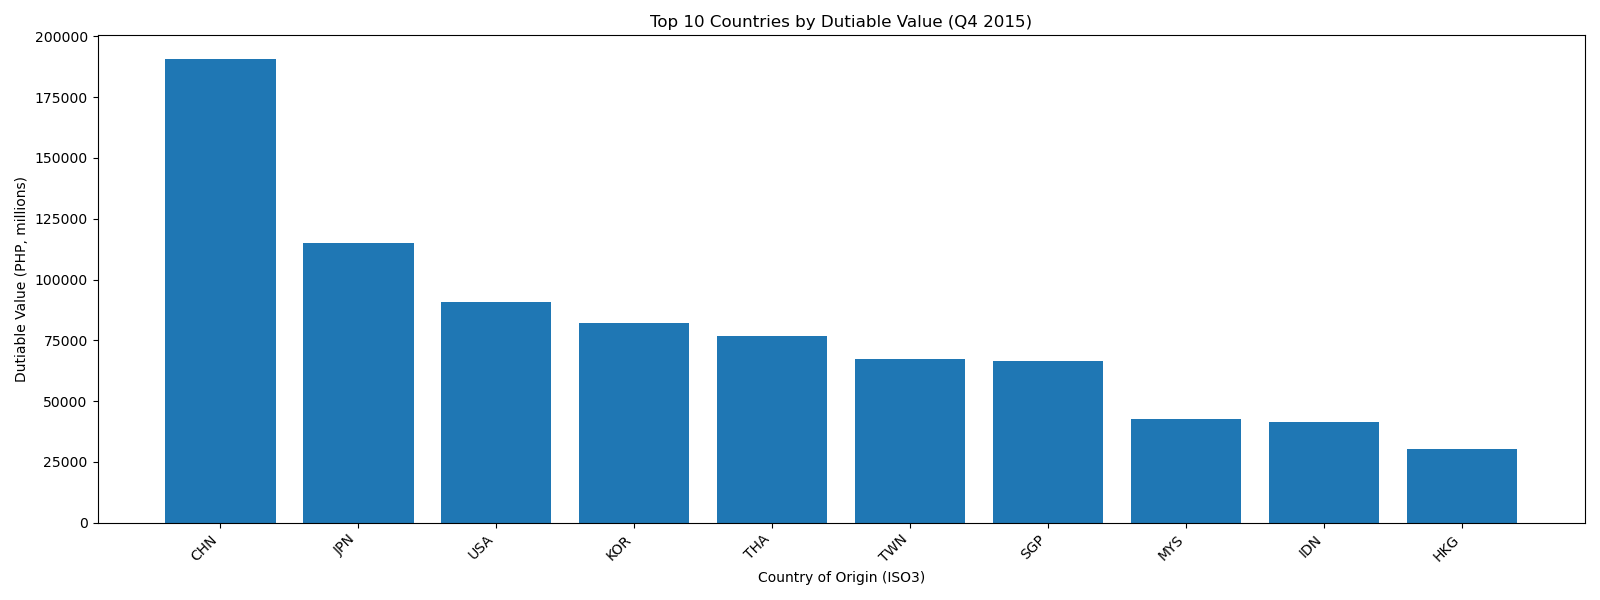

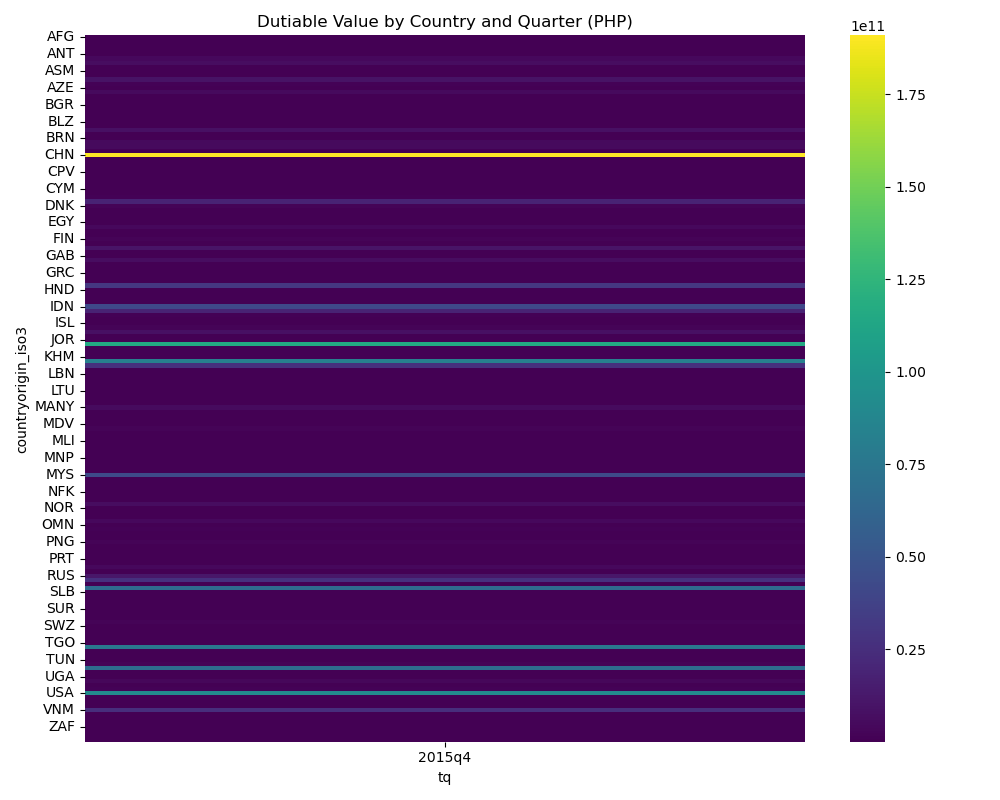

In [4]:
from plotting import plot_bar, plot_heatmap
import config
from IPython.display import Image, display

plot_bar(top10, config.OUTPUT_DIR / 'bar.png', config)
plot_heatmap(pivot, config.OUTPUT_DIR / 'heatmap.png')

display(Image(str(config.OUTPUT_DIR / 'bar.png')))
display(Image(str(config.OUTPUT_DIR / 'heatmap.png')))

## 5. NumPy: Loop vs Vectorized Comparison

In [5]:
from plotting import compare_loop_vs_vectorized

result = compare_loop_vs_vectorized(
    filtered[config.MEASURE_COLUMN].values, threshold=1_000_000
)
result

{'loop_result': 8867,
 'vectorized_result': 8867,
 'median_loop_time_sec': 0.0028900420002173632,
 'median_vectorized_time_sec': 6.454199319705367e-05}

## 6. Validation

In [6]:
from validation import build_validation_rows
import pandas as pd

rows = build_validation_rows(
    raw_df=df, filtered_df=filtered, excluded_df=proc.excluded_df,
    grouped_df=grouped, pivot_df=pivot,
    loop_vs_vectorized_result=result,
)
pd.DataFrame(rows)

,check,expected,actual,tolerance,pass
0,raw_row_count_vs_reference,2.236612e+06,2236612,0.0,True
1,raw_measure_sum_vs_reference,3.587267e+12,3587267375257,1.0,True
2,raw_equals_selected_plus_excluded,2.236612e+06,2236612,0.0,True
3,grouped_row_counts_sum_to_selected,7.214220e+05,721422,0.0,True
4,grouped_sum_matches_independent_sum,1.047601e+12,1047601025694,1.0,True
5,pivot_interior_sum_matches_independent_sum,1.047601e+12,1047601025694,1.0,True
6,top10_values_match_grouped_table,8.037606e+11,803760628409,1.0,True
7,loop_vs_vectorized_agree,8.867000e+03,8867,0.0,True
